# GB84 Model Testing Using in-situ measurements from Cabauw, NL

A notebook to perform test runs with the python implementation of the Georgakakos and Bras model from *"A Hydrologically Useful Station Precipitation Model"* (1984)

This Jupyter Notebook tests a precipitation model using validated data from the CESAR network as inputs, with a 10min resolution.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.
#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature



In [10]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f

# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data


After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.


In [11]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-04 00:00:00"
slice_tuple = tuple(slice_str.split(", "))

#### CESAR surface measurements 

In [12]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [13]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Radiometer LWP 

The liquid water path as measured from the MWR in Cabauw, to be used as the initial state

In [14]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')

C:\Users\chari\AppData\Local\Temp\ipykernel_28992\3086603202.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')


Storing the time values and the timestep.

In [15]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [16]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\ES25\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


### Testing the model

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions `(time)`.


In [17]:
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))

#### Model running loop

Loop for the thermodynamical calculations at each timestep and then for the calculation of precipitation rates and state propagation in time

In [18]:
#loop for finding the precipitation given the T_0 and p

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #thermodynamics and in cloud calculations
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)

    #fluxes
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water

    #precipitation
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]

    #state update
    if i<(len(T_surf)-1):
        X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])


C:\Users\chari\AppData\Local\Temp\ipykernel_28992\3320343293.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]


### Plots and results

C:\Users\chari\AppData\Local\Temp\ipykernel_28992\1264924727.py:130: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tick_times = pd.date_range(start=start_time, end=end_time, freq=f'{tick_interval}H')


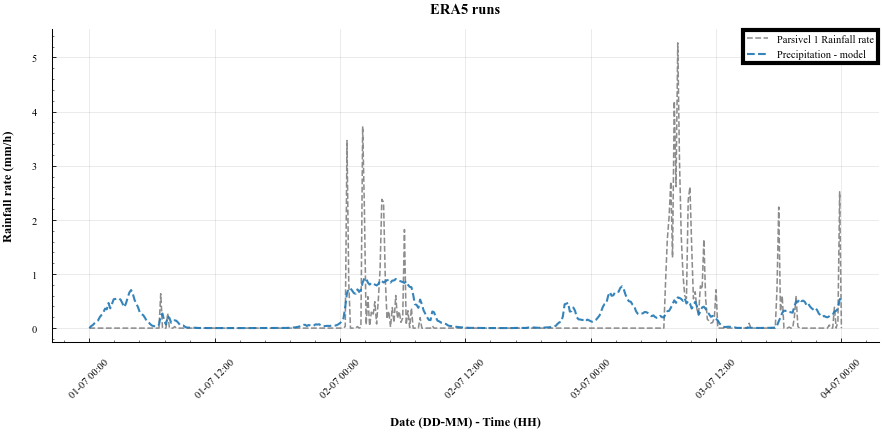

In [19]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.25  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model': '#1f77b4',       # Blue
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                        linestyle='--', 
                       color=colors['parsivel'], 
                       label='Parsivel 1 Rainfall rate',
                       linewidth=1.5 * SCALE_FACTOR,
                       alpha=0.9)

line_model = ax.plot(time, P * 3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Precipitation - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('ERA5 runs', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates
import pandas as pd

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 12  # Daily for small size
    date_format = '%d-%m %H:%M'
    rotation = 45

# Force ticks to align with midnight (00:00) and specified intervals
start_time = pd.to_datetime(time).min().floor('D')  # Start of first day
end_time = pd.to_datetime(time).max()

# Create evenly spaced ticks starting from midnight
tick_times = pd.date_range(start=start_time, end=end_time, freq=f'{tick_interval}H')

ax.set_xticks(tick_times)
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)